<font size="5" color="red"><b>ch3. 분류분석</b></font>
# 1절. 분류분석 개요
## 1-1 분류분석이란? 
- 타겟변수가 categorical인 분석
    * ex. 고객등급예측, 휴먼고객예측, 상품구매예측, 보험사기자예측
    * 수업ex. mnist 숫자데이터분류 예측, iris분류예측, 와인등급예측, 질병예측
- sklearning 패키지 : 머신러닝 모형, 예제데이터셋, 전처리 등의 기능 제공

## 1-2 샘플용 데이터 셋 접근
### load 계열(패키지 내에 데이터 있음)
    - load_iris(), load_boston(), load_diabetes()...
### fetch 계열(패키지 내에 데이터가 없고, 인터넷 연결시 다운)
    - fetch_openml(), fetch_rov1(로이터뉴스 말뭉치)
### make 계열(가상의 데이터 생성)
    - make_classification() : 분류분석용 데이터 생성
    - make_regression() : 회귀분석용 데이터 생성
    - make_blobs() : 군집분석용 데이터 생성(타겟변수 x)

In [3]:
from tensorflow.keras.datasets import mnist
import matplotlib.pyplot as plt
# mnist load
(X_train, y_train), (X_test, y_test) = mnist.load_data()
X_train.shape, y_train.shape, X_test.shape, y_test.shape

((60000, 28, 28), (60000,), (10000, 28, 28), (10000,))

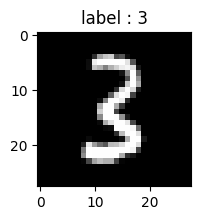

In [4]:
# 첫번째 이미지 출력
plt.figure(figsize=(2,2))
plt.imshow(X_train[50000], cmap='gray')
plt.title("label : {}".format(y_train[50000]))
plt.show()

In [8]:
# fetch 계열(패키지 내에 데이터가 없고, 인터넷 연결시 다운)
from sklearn.datasets import fetch_openml
# mnist fetch : mnist, iris, boston, fashon-mnist ....
mnist = fetch_openml(name="mnist_784", version=1, as_frame=False, parser="auto")
X, y = mnist.data, mnist.target.astype('int')
X.shape, y.shape

((70000, 784), (70000,))

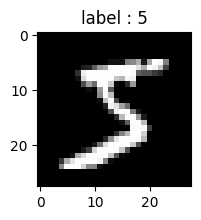

In [9]:
X = X.reshape(-1, 28,28)
# 첫번째 이미지 출력
plt.figure(figsize=(2,2))
plt.imshow(X[0], cmap='gray')
plt.title('label : {}'.format(y[0]))
plt.show()

# 2절. 분류분석의 종류
- predict()
## 2-1 확률적 모형
    - 주어진 데이터에 각 클래스가 정답일 확률을 계산하는 모형
    - predict_proba() : 각 분류 클래스별 확률을 알려줌(일부의 판별함수 모형에 있긴 함)
    - predict_log_proba() : 확률의 로그값을 알려줌

### 1) 확률적 생성 모형
    - 각 클래스별 특정 데이터 확률분포 추정(베이즈 정리를 사용), 소량의 데이터로도 작동
    - ex. Quadratic Discriminant Analysis, 나이브 베이지안

### 2) 확률적 판별 모형
    - 확률을 계산하는 함수 이용
    - ex. 의사결정나무, 로지스틱 회귀

## 2-2 판별함수 모형
    - 주어진 데이터를 클래스에 따라 서로 다른 영역으로 나누는 경계면을 찾은 후,
    - 이 경계면으로부터 어느 위치에 있는지를 계산하는 판별함수를 이용
    - decision_function()
    - ex. 퍼셉트론, 서포트벡터머신, MLP(신경망)

=> RandomRorest, LGBM, XGBoost, CatBoost 등의 앙상블 모형이 더 많이 쓰임

# 3절 분류모형1. 확률적 생성 모형
- 베이즈 정리를 사용하여 확률분포 계산

## 3-1 QDA(Quadratic Discriminant Analysis)
- X가 연속형(실수)이면서 정규분포라고 가정함

In [12]:
# 샘플 데이터
from sklearn.datasets import make_classification
X, y = make_classification(n_features=2,        # 독립변수 갯수
                           n_informative=2,     # 타겟변수에 영향을 주는 독립변수 갯수
                           n_redundant=0,       # 타겟변수에 영향을 안 주는 독립변수 갯수
                           n_clusters_per_class=1, # 클래스 내 서브 그룹수
                           n_classes=2,         # 타겟변수 class 수
                           n_samples=100,       # 데이터 갯수(행수. 기본값)
                           random_state=9)
X.shape, y.shape


((100, 2), (100,))

In [13]:
import numpy as np
np.unique(y)

array([0, 1])

In [14]:
y.mean()

0.5

In [16]:
# y= 1인 데이터
X[y==1].shape

(50, 2)

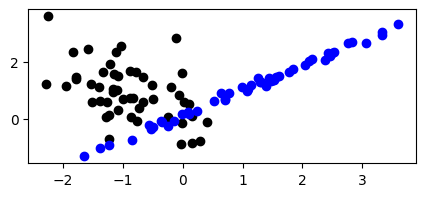

In [18]:
import matplotlib.pyplot as plt
plt.figure(figsize=(5,2))
plt.scatter(X[y==0,0], X[y==0,1], c='k')
plt.scatter(X[y==1,0], X[y==1,1], c='b')

In [19]:
# (0,0)
X[y==1] = -X[y==0]

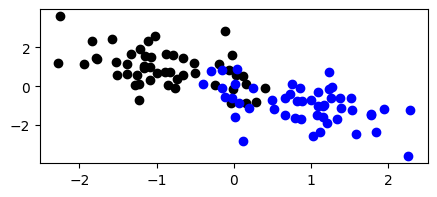

In [20]:
import matplotlib.pyplot as plt
plt.figure(figsize=(5,2))
plt.scatter(X[y==0,0], X[y==0,1], c='k')
plt.scatter(X[y==1,0], X[y==1,1], c='b')

In [21]:
# QDA
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis
model = QuadraticDiscriminantAnalysis()
model.fit(X, y)

QuadraticDiscriminantAnalysis()

In [22]:
x = [[5,5]] # 2차원 데이터 predict
model.predict(x)[0]

1

In [23]:
p = model.predict_proba(x)
print(p) # 0으로 분류될 확률, 1로 분류될 확률

[[8.84215536e-06 9.99991158e-01]]


In [ ]:
model.classes_ # 분류될 내용

array([0, 1])

In [25]:
import pandas as pd
y_hat = model.predict(X)
y_hat

array([0, 1, 1, 0, 1, 0, 1, 1, 0, 1, 0, 0, 1, 1, 1, 0, 1, 1, 0, 1, 1, 1,
       0, 0, 1, 1, 1, 0, 0, 0, 1, 1, 1, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 1, 1, 1, 0, 1, 0, 1, 0, 1, 1, 0, 0, 1, 1, 0, 0, 1,
       1, 0, 1, 0, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 0, 0,
       0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 1])

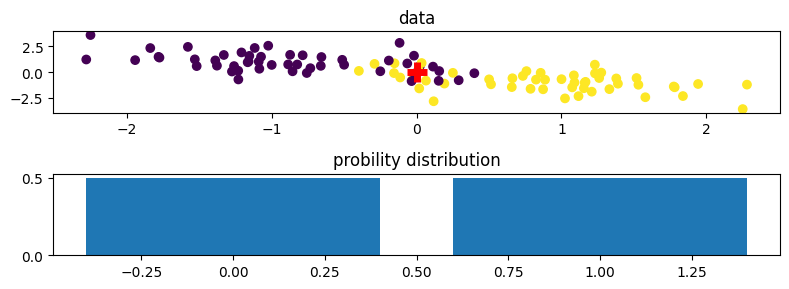

In [31]:
x = [[0,0]]
plt.figure(figsize=(8,3))
p = model.predict_proba(x)
plt.subplot(211) # 2행1열로 plt 그래프 중 첫번째 그래프 (2, 1, 1)
plt.scatter(x=X[:,0], y=X[:,1], c=y)
plt.scatter(x=x[0][0], y=x[0][1], c='r', s=200, marker='+', lw=5)
plt.title('data')
plt.subplot(212) # 2행 1열로 plt 그래프 중 두번째 그래프 (2,1,2)
plt.bar(model.classes_, p[0])
plt.title('probility distribution')
plt.tight_layout()
plt.show()

In [30]:
model.predict(x)

array([0])

### 3-2 나이브베이지안 모형

In [ ]:
# 데이터
import seaborn as sns
iris = sns.load_dataset('iris')
X = iris.iloc[:, :-1].values
y = iris.iloc[:, -1].values # 범주형(문자) - 라벨인코딩 없이 적용
# 모형생성
from sklearn.naive_bayes import MultinomialNB
model = MultinomialNB()
model.fit(X, y) # 학습데이터는 numpy 배열로


MultinomialNB()

In [38]:
test_x = np.array([[5.1,3.5,1.4,0.2]]) # X.loc[0]
print(model.classes_)
print('test_X의 예측 :', model.predict(test_x))
print('test_X의 확률 :', model.predict_proba(test_x))

['setosa' 'versicolor' 'virginica']
test_X의 예측 : ['setosa']
test_X의 확률 : [[0.75199536 0.16092948 0.08707516]]


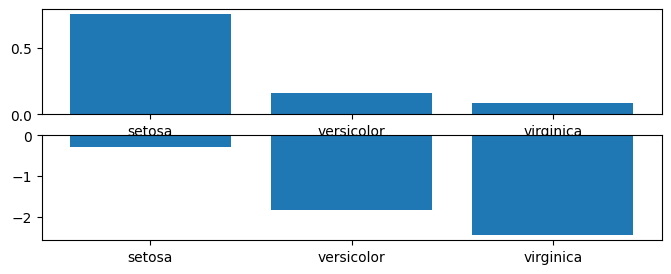

In [44]:
test_x = np.array([[5.1,3.5,1.4,0.2]]) # X.loc[0]
plt.figure(figsize=(8,3))
plt.subplot(2, 1, 1)
plt.bar(model.classes_, model.predict_proba(test_x)[0])
plt.subplot(2, 1, 2)
plt.bar(model.classes_, model.predict_log_proba(test_x)[0])
plt.show()

- 두 subplot을 한꺼번에 출력.

---

## ✅ 🌳 왜 이렇게 그리나요?

| 함수                   | 의미                           | 값 범위        |
|----------------------|----------------------------|-------------|
| `predict_proba()`    | **각 클래스별 확률**     | 0 ~ 1      |
| `predict_log_proba()`| **로그 확률**              | 음수 (log p) |

- 위쪽 subplot: 실제 **확률 분포** 확인
- 아래쪽 subplot: 로그 확률 → 작을수록 예측이 덜 확실한 클래스

---

## ✅ 💡 요약

- 위: 확률(bar)
- 아래: 로그 확률(bar)
- `model.classes_`: x축 클래스 이름

---


In [2]:
import io
from sklearn.tree import export_graphviz
# conda install graphviz
import pydot # pip install pydot
from IPython.core.display import Image

In [3]:
def draw_decision_tree(model, feature_names):
 dot_buf = io.StringIO()
 export_graphviz(model, out_file=dot_buf, feature_names=feature_names)
 graph = pydot.graph_from_dot_data(dot_buf.getvalue())[0]
 image = graph.create_png()
 return Image(image)